In [136]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import yfinance as yf


## Functions 

In [ ]:
def Pagan_test(data): 
    # Create DataFrame from data dictionary
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    # Drop rows with missing values to avoid errors during modeling
    df = df.dropna()

    # Build the formula string dynamically from your independent variables
    independent_vars = "+".join([f"X{i}" for i in range(1, len(df.columns))])
    formula = f"Y ~ {independent_vars}"

    # Fit the OLS regression model
    model = smf.ols(formula=formula, data=df).fit()

    # Run the Breusch-Pagan test
    bp_test = sms.het_breuschpagan(model.resid, model.model.exog)
    labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']

    # Print Breusch-Pagan test results
    for label, value in zip(labels, bp_test):
        print(f"{label}: {value}")

def robust_regression(data, cov_type='HC3'):
    """
    Fit OLS regression with robust standard errors (Huber-White)
    
    Parameters:
    -----------
    data : dict or DataFrame
        Data with 'Y' as dependent variable and 'X1', 'X2', etc. as independent variables
    cov_type : str, default 'HC3'
        Type of robust covariance matrix ('HC0', 'HC1', 'HC2', 'HC3')
        HC3 is recommended for most cases
    
    Returns:
    --------
    Fitted regression model with robust standard errors
    """
    # Create DataFrame from data dictionary
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df = data

    # Drop rows with missing values to avoid errors during modeling
    df = df.dropna()

    # Build the formula string dynamically from your independent variables
    independent_vars = "+".join([f"X{i}" for i in range(1, len(df.columns))])
    formula = f"Y ~ {independent_vars}"

    # Fit the OLS regression model with robust standard errors
    model = smf.ols(formula=formula, data=df).fit(cov_type=cov_type)

    # Print summary
    print(model.summary())
    
    return model

def Whites_test(data):
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    X = df[[f'X{i}' for i in range(1, len(df.columns))]]
    X = sm.add_constant(X)
    y = df['Y']

    model = sm.OLS(y, X).fit()

    white_test = sms.het_white(model.resid, model.model.exog)

    labels = ['Test Statistic', 'Test Statistic p-value', 'F-Statistic', 'F-Test p-value']
    for label, value in zip(labels, white_test):
        print(f"{label}: {value}")

def p_valueTest(data):

    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    # Assume df is your DataFrame with independent variables X1, X2,... and dependent variable Y
    X = df.drop('Y', axis=1)
    y = df['Y']

    # Add a constant to the model (intercept)
    X = sm.add_constant(X)

    # Fit the model
    model = sm.OLS(y, X).fit()

    # Get summary which includes p-values
    print(model.summary())

    # Or just get the p-values directly:
    p_values = model.pvalues
    print(p_values)

def LRM(data): 

    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":

        df = pd.DataFrame(data)
    else: 
        df=data

    df = std_filter(df)  # remove rows with missing data

    X = df.drop('Y', axis=1)
    y = df['Y']

    # Initialize and fit the model
    model = LinearRegression()
    model.fit(X, y)

    Coefs = []

    # Print coefficients to show the importance of each variable
    for var, coef in zip(X.columns, model.coef_):
        Coefs.append([var, coef])

    return Coefs

def VIF_test(data):
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    # Exclude dependent variable Y for VIF calculation
    X = df[[f"X{i}" for i in range(1, len(df.columns))]]

    # Add constant term for intercept
    X = sm.add_constant(X)

    # Calculate VIF for each explanatory variable
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    print(vif_data)

def std_filter(data):
    means = data.mean()
    stds = data.std()    

    filtered_values = []

    for idx in range(len(data)):
        row = data.iloc[idx]

        # Check if every column's value is within mean ± std specifically for that column
        in_range = ((row >= (means - stds)) & (row <= (means + stds))).all()

        if in_range:
            filtered_values.append(row)

    df_filtered = pd.DataFrame(filtered_values, columns=data.columns)
    return df_filtered

def plot_data_log(data): 
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    y = df.index

    for i in data: 
        plt.plot(df[i],y, label=i, marker='o', markersize=1, linestyle='')

    plt.xscale('log')

    # plt.plot(df[i], y, label="nvda", marker='o', markersize=1, linestyle='')

    plt.legend()
    plt.xlabel('Independent Variables (Log Scale)')
    plt.ylabel('NVIDIA Stock Price (Y)')
    plt.title('Stock Prices vs NVIDIA Stock Price')

def plot_data_log_y(data, dotsize=1): 
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    for i in data: 

        if i == "Y":
            continue

        plt.plot(df[i], df["Y"], label=i, marker='o', markersize=dotsize, linestyle='')

    plt.xscale('log')

    # plt.plot(y,df["Y"], label="nvda", marker='o', markersize=1, linestyle='')

    plt.legend()
    plt.xlabel('Independent Variables (Log Scale)')
    plt.ylabel('NVIDIA Stock Price (Y)')
    plt.title('Stock Prices vs NVIDIA Stock Price')

def plot_data_log_SAVE(data): 
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    y = df.index

    for i in data: 
        plt.plot(df[i], y, label=i)

    plt.xscale('log')

    plt.plot(df["Y"], y, label="nvda")

    plt.legend()

    plt.xlabel('Independent Variables (Log Scale)')
    plt.ylabel('NVIDIA Stock Price (Y)')
    plt.title('Stock Prices vs NVIDIA Stock Price')

    plt.savefig('my_high_res_plot.png', dpi=300)
    for i in data: 
        i.index = index

def calculate_slopes(data_dict):
    slopes = {}
    
    for key, series in data_dict.items():
        if key == "Y":
            continue  # skip dependent variable
        
        # Drop NaNs and align index
        y = series.dropna().values
        x = np.arange(len(y))  # time index
        
        # Linear regression slope
        slope = np.polyfit(x, y, 1)[0]
        slopes[key] = slope
    
    return slopes

def correlation_matrix(data_dict):
    df = pd.DataFrame(data_dict)
    X = df.drop(columns="Y").dropna()
    return X.corr()

def plot_correlation_matrix_rotate(corr_df, title):
    fig, ax = plt.subplots()
    cax = ax.imshow(corr_df.values)
    fig.colorbar(cax)

    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_df.index)

    for i in range(len(corr_df.index)):
        for j in range(len(corr_df.columns)):
            ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}",
                    ha="center", va="center")

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_correlation_matrix(corr_df, title):
    fig, ax = plt.subplots()
    cax = ax.imshow(corr_df.values)
    fig.colorbar(cax)

    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_yticklabels(corr_df.index)

    for i in range(len(corr_df.index)):
        for j in range(len(corr_df.columns)):
            ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}",
                    ha="center", va="center")

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def getRidOfTimeStamp(df): 
    df = pd.DataFrame(df)
    df_copy = df.copy()
    df_copy.index = df_copy.index.astype(str).str[:10]
    df_copy.index = df_copy.index
    return df_copy


## Stocks import

In [225]:
nvda = yf.Ticker("NVDA") #
asml = yf.Ticker("ASML") #
aapl = yf.Ticker("AAPL") #
goog = yf.Ticker("GOOG") #
tsmc = yf.Ticker("TSM") #

s_p = yf.Ticker("^GSPC")
ndx = yf.Ticker("^NDX")
# spgtsi = yf.Ticker("^SPGSTI")

amd = yf.Ticker("AMD")
intel = yf.Ticker("INTL")


copper = yf.Ticker("HG=F")
gold = yf.Ticker("GC=F")
silver = yf.Ticker("SI=F")
platinum = yf.Ticker("PL=F")

gold_etf = yf.Ticker("GLD")
silver_etf = yf.Ticker("SLV")
copper_etf = yf.Ticker("CPER")
platinum_etf = yf.Ticker("PPLT")
uranium_etf = yf.Ticker("URA")

nuscale = yf.Ticker("SMR")
oklo = yf.Ticker("OKLO")
ge_vernova = yf.Ticker("GEV")
bwx = yf.Ticker("BWXT")
nano_nuclear = yf.Ticker("NNE")

qcom = yf.Ticker("QCOM")

### MODEL 1: Related Stocks

In [240]:
data1 = {
    "Y": nvda.history(start="2020-01-01")['Close'],
    "X1": asml.history(start="2020-01-01")['Close'],
    "X2": aapl.history(start="2020-01-01")['Close'],
    # "X3": goog.history(start="2020-01-01")['Close'],
    "X3": tsmc.history(start="2020-01-01")['Close'],
    # "X4": intel.history(start="2020-01-01")['Close'],
    "X4": qcom.history(start="2020-01-01")['Close']
}

In [140]:
LRM1 = LRM(data1)

for i in LRM1:
    print(i)    

['X1', -0.03931433412009034]
['X2', 0.3793664083199755]
['X3', 0.8878530528947072]
['X4', -1.8808646805047828]
['X5', 0.1319995072103596]


In [141]:
p_valueTest(data1)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     5456.
Date:                Fri, 06 Feb 2026   Prob (F-statistic):               0.00
Time:                        09:51:25   Log-Likelihood:                -2912.5
No. Observations:                 796   AIC:                             5837.
Df Residuals:                     790   BIC:                             5865.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -113.9557      8.514    -13.385      0.0

In [142]:
Pagan_test(data1)

Lagrange multiplier statistic: 60.31403576635237
p-value: 1.0467360892766185e-11
f-value: 12.953377003747145
f p-value: 3.938634944753807e-12


In [143]:
Whites_test(data1)

Test Statistic: 122.84875483574783
Test Statistic p-value: 8.442720389856321e-17
F-Statistic: 7.07179743643447
F-Test p-value: 2.1311842029770005e-18


In [241]:
VIF_test(data1)

  Variable        VIF
0    const  25.265597
1       X1   3.997651
2       X2   5.304632
3       X3   4.293950
4       X4   3.281611


In [145]:
calculate_slopes(data1)

{'X1': 0.377894554653139,
 'X2': 0.10745990947061611,
 'X3': 0.11952209783293154,
 'X4': 0.011805898680305765,
 'X5': 0.04773232062425985}

In [146]:
corr_df = correlation_matrix(data1)

corr_df

,X1,X2,X3,X4,X5
X1,1.000000,0.606468,0.714390,0.731761,0.702395
X2,0.606468,1.000000,0.889207,0.826786,0.666666
X3,0.714390,0.889207,1.000000,0.965057,0.690127
X4,0.731761,0.826786,0.965057,1.000000,0.645687
X5,0.702395,0.666666,0.690127,0.645687,1.000000


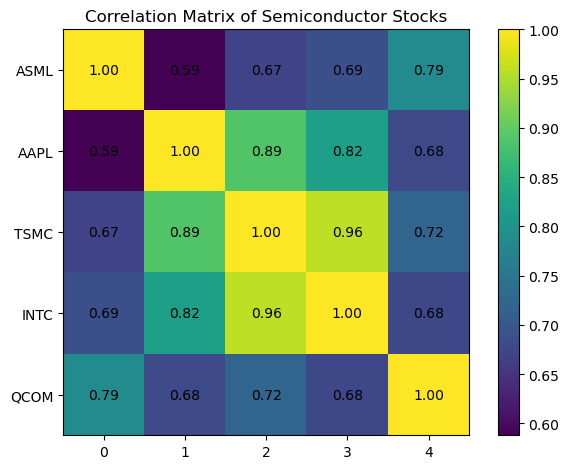

Text(0.5, 1.0, 'Correlation Matrix of Raw Metals')

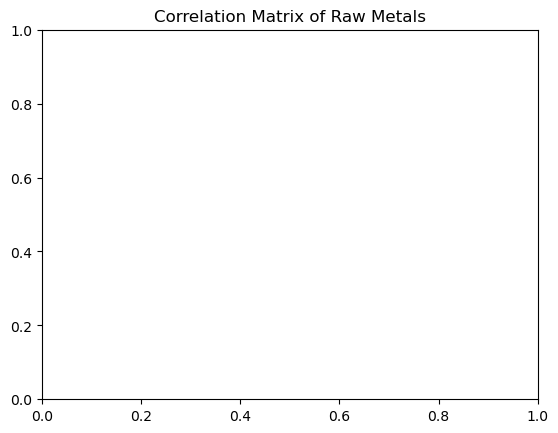

In [147]:
corr_df = pd.DataFrame(
    [
        [1.0, 0.587855, 0.670145, 0.687818, 0.786786],
        [0.587855, 1.0, 0.888377, 0.821160, 0.678486],
        [0.670145, 0.888377, 1.0, 0.960664, 0.722288],
        [0.687818, 0.821160, 0.960664, 1.0, 0.677420],
        [0.786786, 0.678486, 0.722288, 0.677420, 1.0]
    ],
    columns=["ASML", "AAPL", "TSMC", "INTC", "QCOM"],
    index=["ASML", "AAPL", "TSMC", "INTC", "QCOM"]
)

plot_correlation_matrix(corr_df, "Correlation Matrix of Semiconductor Stocks")
plt.title("Correlation Matrix of Raw Metals")

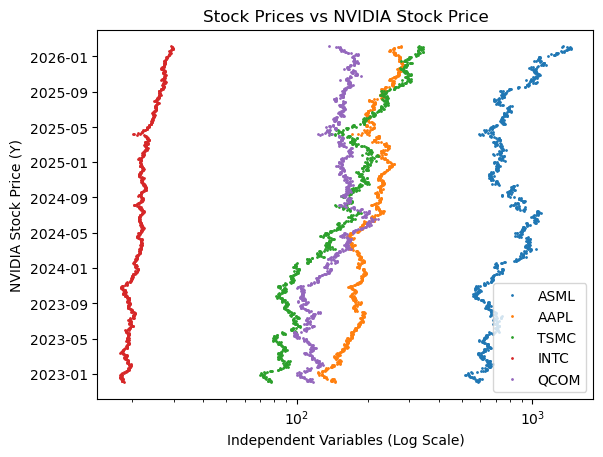

In [148]:
data1_plot = {
    "ASML": asml.history(start="2020-01-01")['Close'],
    "AAPL": aapl.history(start="2020-01-01")['Close'],
    # "X3": goog.history(start="2020-01-01")['Close'],
    "TSMC": tsmc.history(start="2020-01-01")['Close'],
    "INTC": intel.history(start="2020-01-01")['Close'],
    "QCOM": qcom.history(start="2020-01-01")['Close']
}

plot_data_log(data1_plot)

### MODEL 2: yearly metal production 

Importing data

In [149]:
silver_data = pd.read_excel('./Data/Silver Historical Statistics.xlsx', sheet_name="Silver")
Tin_data = pd.read_excel('./Data/Tin Historical Statistics.xlsx', sheet_name="Tin")
Silicon_data = pd.read_excel('./Data/Silicon Historical Statistics.xlsx', sheet_name="Silicon")
Aluminum_data = pd.read_excel('./Data/Aluminum Historical Statistics.xlsx', sheet_name="Aluminum")
Rare_Earths_data = pd.read_excel('./Data/Rare Earths Historical Statistics.xlsx', sheet_name="Rare earths")
Gold_data = pd.read_excel('./Data/Gold Historical Statistics.xlsx', sheet_name="Gold")

filtered_silver_data = silver_data[(124-20):124]["Unnamed: 11"]
filtered_Tin_data = Tin_data[(124-20):124]["Unnamed: 11"] 
filtered_Silicon_data = Silicon_data[(102-21):101]["Unnamed: 9"] 
filtered_Aluminum_data = Aluminum_data[(124-20):124]["Unnamed: 15"] 
filtered_Rare_Earths_data = Rare_Earths_data[(124-20):124]["Unnamed: 7"] 
filtered_Gold_data = Gold_data[(124-20):124]["Unnamed: 8"]

filtered_Silicon_data

81     3500000
82     3500000
83     3720000
84     4390000
85     4900000
86     5310000
87     5650000
88     6330000
89     6510000
90     6260000
91     6930000
92     7370000
93     7450000
94     7950000
95     7900000
96     7800000
97     7700000
98     7230000
99     8890000
100    8560000
Name: Unnamed: 9, dtype: object

In [150]:
filtered_Gold_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index
filtered_silver_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index
filtered_Tin_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index
filtered_Silicon_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index
filtered_Aluminum_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index
filtered_Rare_Earths_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index

In [151]:
data2 = {
    "Y": nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last(),
    "X1": filtered_silver_data.astype(float),
    "X2": filtered_Tin_data.astype(float),
    "X3": filtered_Silicon_data.astype(float),
    "X4": filtered_Aluminum_data.astype(float),
    "X5": filtered_Rare_Earths_data.astype(float),
    "X6": filtered_Gold_data.astype(float)
}

In [152]:
for i in LRM(data2):
    print(i)

['X1', 1.3778891459543472e-07]
['X2', -1.0403274364549552e-06]
['X3', 2.454517758690049e-07]
['X4', -2.9934311364900985e-08]
['X5', 2.8183344598433754e-06]
['X6', 4.194284459384738e-09]


In [153]:
p_valueTest(data2
        )

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     18.68
Date:                Fri, 06 Feb 2026   Prob (F-statistic):           1.07e-05
Time:                        09:51:27   Log-Likelihood:                -15.411
No. Observations:                  20   AIC:                             44.82
Df Residuals:                      13   BIC:                             51.79
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2456      3.882     -0.063      0.9

In [154]:
Pagan_test(data2)

Lagrange multiplier statistic: 6.3585464981289475
p-value: 0.38424625900242865
f-value: 1.0099254264991946
f p-value: 0.4598834856886022


In [155]:
Whites_test(data2)

Test Statistic: 20.0
Test Statistic p-value: 0.39457818208600104
F-Statistic: nan
F-Test p-value: nan


In [156]:
VIF_test(data2)

  Variable         VIF
0    const  716.719690
1       X1   18.100771
2       X2    1.823068
3       X3   30.965129
4       X4   73.379265
5       X5    3.287107
6       X6   11.975217


In [157]:
corr_df2 = correlation_matrix(data2)

corr_df2

,X1,X2,X3,X4,X5,X6
X1,1.000000,0.641283,0.899590,0.947358,0.487758,0.832391
X2,0.641283,1.000000,0.569233,0.644998,0.437450,0.629949
X3,0.899590,0.569233,1.000000,0.949741,0.639173,0.689657
X4,0.947358,0.644998,0.949741,1.000000,0.676723,0.861907
X5,0.487758,0.437450,0.639173,0.676723,1.000000,0.585566
X6,0.832391,0.629949,0.689657,0.861907,0.585566,1.000000


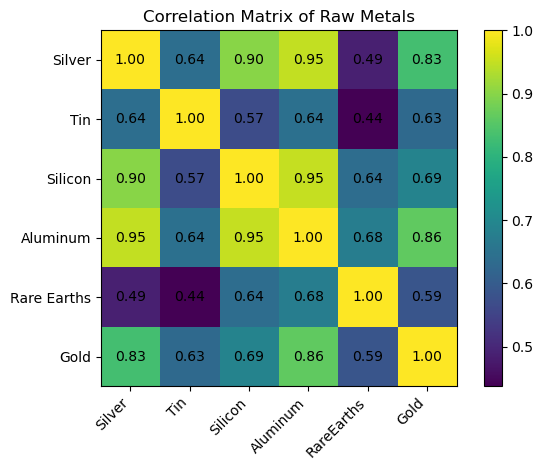

In [158]:
corr_df2 = pd.DataFrame(
    [
        [1.000000, 0.641283, 0.899590, 0.947358, 0.487758, 0.832391],
        [0.641283, 1.000000, 0.569233, 0.644998, 0.437450, 0.629949],
        [0.899590, 0.569233, 1.000000, 0.949741, 0.639173, 0.689657],
        [0.947358, 0.644998, 0.949741, 1.000000, 0.676723, 0.861907],
        [0.487758, 0.437450, 0.639173, 0.676723, 1.000000, 0.585566],
        [0.832391, 0.629949, 0.689657, 0.861907, 0.585566, 1.000000]
    ],
    columns=["Silver", "Tin", "Silicon", "Aluminum", "RareEarths", "Gold"],
    index=["Silver", "Tin", "Silicon", "Aluminum", "Rare Earths", "Gold"]
)

plot_correlation_matrix_rotate(corr_df2, "Correlation Matrix of Raw Metals")

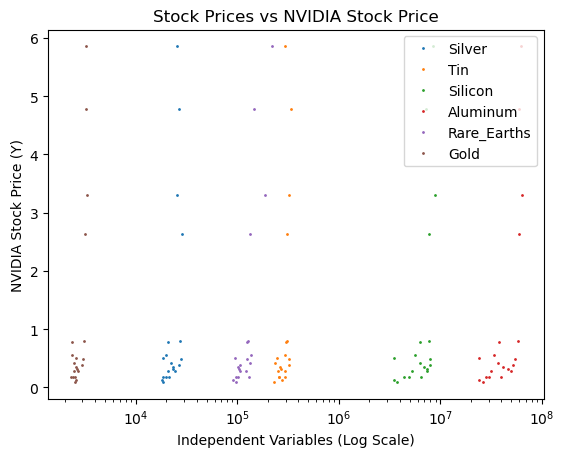

In [159]:
data2_plot = {
    "Y": nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last(),
    "Silver": filtered_silver_data.astype(float),
    "Tin": filtered_Tin_data.astype(float),
    "Silicon": filtered_Silicon_data.astype(float),
    "Aluminum": filtered_Aluminum_data.astype(float),
    "Rare_Earths": filtered_Rare_Earths_data.astype(float),
    "Gold": filtered_Gold_data.astype(float)
}

plot_data_log_y(data2_plot)

## MODEL 3: Daily metal prices

In [242]:
data3 = {
    "X1": copper.history(start="2020-01-01")['Close'], 
    "X2": gold.history(start="2020-01-01")['Close'],
    "X3": silver.history(start="2020-01-01")['Close'],
    "X4": platinum.history(start="2020-01-01")['Close'], 

    "Y": nvda.history(start="2020-01-01")['Close'], 
}

In [161]:
for i in LRM(data3):
    print(i)

['X1', -9.612849869798733]
['X2', 0.07586891874366007]
['X3', 2.095895278512972]
['X4', -0.0496055189208131]
['X5', 2.0757091686123004]


In [243]:
p_valueTest(data3)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     3438.
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:38:46   Log-Likelihood:                -6660.4
No. Observations:                1535   AIC:                         1.333e+04
Df Residuals:                    1530   BIC:                         1.336e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -110.2274      3.741    -29.468      0.0

In [244]:
Pagan_test(data3)

Lagrange multiplier statistic: 500.4383225431939
p-value: 5.385819006559209e-107
f-value: 185.0229546906482
f p-value: 2.0623721715046692e-129


In [245]:
Whites_test(data3)

Test Statistic: 679.5170875601577
Test Statistic p-value: 6.055413774459583e-136
F-Statistic: 86.23917539707818
F-Test p-value: 2.2837130350686432e-181


In [246]:
VIF_test(data3)

  Variable        VIF
0    const  62.263310
1       X1   2.063572
2       X2   6.616278
3       X3  16.955074
4       X4   7.975621


In [247]:
correlation_matrix(data3)

,X1,X2,X3,X4
X1,1.000000,0.688628,0.700194,0.667961
X2,0.688628,1.000000,0.905677,0.781002
X3,0.700194,0.905677,1.000000,0.924637
X4,0.667961,0.781002,0.924637,1.000000


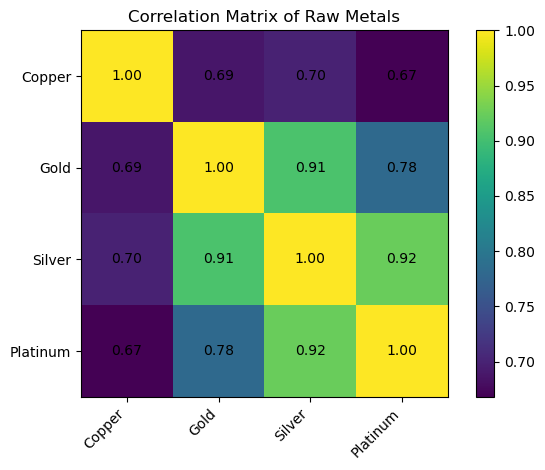

In [248]:
corr_df3 = pd.DataFrame(
    [
        [1.000000, 0.688628, 0.700194, 0.667961],
        [0.688628, 1.000000, 0.905677, 0.781002],
        [0.700194, 0.905677, 1.000000, 0.924637],
        [0.667961, 0.781002, 0.924637, 1.000000]
    ],
    columns=["Copper", "Gold", "Silver", "Platinum"],
    index=["Copper", "Gold", "Silver", "Platinum"]
)

plot_correlation_matrix_rotate(corr_df3, "Correlation Matrix of Raw Metals")

## MODEL 4: Monthly electricity rates

In [166]:
Excel_elec = pd.read_excel('./Data/EE-Data1.xlsx', sheet_name='Sheet1')

commercial_elec_price = Excel_elec["Unnamed: 1"][14:81].astype('float64')
industrial_elec_price = Excel_elec["Unnamed: 2"][14:81].astype('float64')

industrial_elec_price

14    6.37
15    6.44
16    6.39
17    6.39
18    6.54
      ... 
75    8.23
76    8.26
77    8.21
78    8.30
79    8.86
Name: Unnamed: 2, Length: 66, dtype: float64

In [167]:
nvda.history(start="2020-01-01", end="2025-7-1")['Close'].resample('ME').last()

Date
2020-01-31 00:00:00-05:00      5.884465
2020-02-29 00:00:00-05:00      6.725745
2020-03-31 00:00:00-04:00      6.564619
2020-04-30 00:00:00-04:00      7.278856
2020-05-31 00:00:00-04:00      8.841314
                                ...    
2025-02-28 00:00:00-05:00    124.885841
2025-03-31 00:00:00-04:00    108.360329
2025-04-30 00:00:00-04:00    108.900230
2025-05-31 00:00:00-04:00    135.105484
2025-06-30 00:00:00-04:00    157.972305
Freq: ME, Name: Close, Length: 66, dtype: float64

In [168]:
commercial_elec_price.index = nvda.history(start="2020-01-01", end="2025-7-1")['Close'].resample('ME').last().index
industrial_elec_price.index = nvda.history(start="2020-01-01", end="2025-7-1")['Close'].resample('ME').last().index

data4 = {
    "X1": commercial_elec_price,
    "X2": industrial_elec_price,
    "Y": nvda.history(start="2020-01-01", end="2025-7-1")['Close'].resample('ME').last()
}

In [169]:
for i in LRM(data4):
    print(i)

['X1', 46.084696717686334]
['X2', -47.050496011590056]


In [170]:
p_valueTest(data4)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     49.94
Date:                Fri, 06 Feb 2026   Prob (F-statistic):           1.01e-13
Time:                        09:51:30   Log-Likelihood:                -312.75
No. Observations:                  66   AIC:                             631.5
Df Residuals:                      63   BIC:                             638.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -387.6682     44.819     -8.650      0.0

In [171]:
Pagan_test(data4)

Lagrange multiplier statistic: 9.424588520396943
p-value: 0.00898414196042773
f-value: 5.247412800515555
f p-value: 0.00780080194634647


In [172]:
Whites_test(data4)

Test Statistic: 16.92781621800738
Test Statistic p-value: 0.004638749664960205
F-Statistic: 4.139489604100928
F-Test p-value: 0.0026931432206392047


In [173]:
VIF_test(data4)

  Variable         VIF
0    const  165.512682
1       X1    8.742090
2       X2    8.742090


## MODEL 5: S&P 500

In [174]:
data5 = {
    "Y": nvda.history(start="2020-01-01")['Close'].pct_change(),
    "X1": s_p.history(start="2020-01-01")['Close'].pct_change(),
}

In [175]:
LRM(data5)

[['X1', 1.1530423368941776]]

In [176]:
p_valueTest(data5)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.492
Model:                            OLS   Adj. R-squared:                  0.492
Method:                 Least Squares   F-statistic:                     1483.
Date:                Fri, 06 Feb 2026   Prob (F-statistic):          2.45e-227
Time:                        09:51:31   Log-Likelihood:                 3554.7
No. Observations:                1531   AIC:                            -7105.
Df Residuals:                    1529   BIC:                            -7095.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.001      2.859      0.0

In [177]:
Pagan_test(data5)

Lagrange multiplier statistic: 0.38986616002284
p-value: 0.5323697620930075
f-value: 0.3894560381483186
f p-value: 0.5326785650692862


In [178]:
Whites_test(data5)

Test Statistic: 3.543174256422419
Test Statistic p-value: 0.17006286295244513
F-Statistic: 1.7722171168988565
F-Test p-value: 0.17030491633228684


In [179]:
VIF_test(data5) #probably not needed

  Variable       VIF
0    const  1.001871
1       X1  1.000000


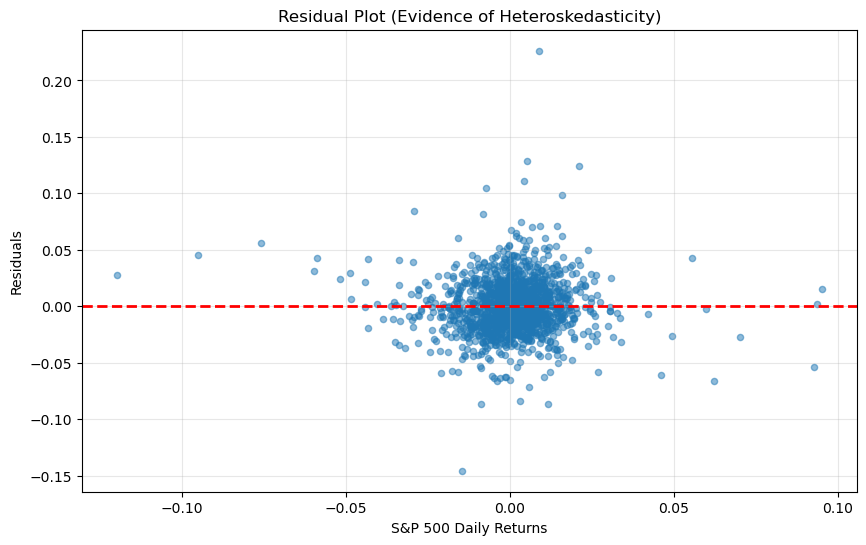

In [180]:
# Calculate residuals
data5['residuals'] = data5['Y'] - (0.0018 + 1.7839 * data5['X1'])

plt.figure(figsize=(10, 6))
plt.scatter(data5['X1'], data5['residuals'], alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('S&P 500 Daily Returns')
plt.ylabel('Residuals')
plt.title('Residual Plot (Evidence of Heteroskedasticity)')
plt.grid(True, alpha=0.3)
plt.show()

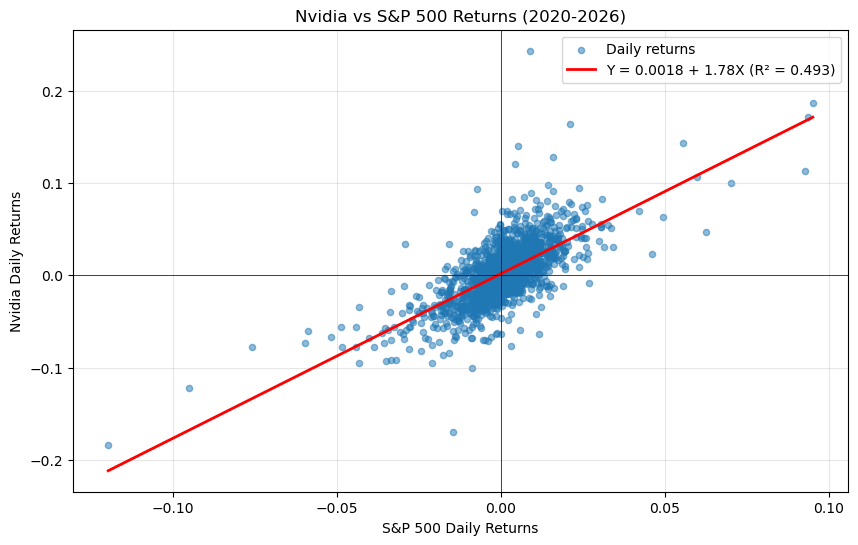

In [181]:
# Prepare data
df = pd.DataFrame(data5).dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['X1'], df['Y'], alpha=0.5, s=20, label='Daily returns')

# Add regression line
x_line = np.linspace(df['X1'].min(), df['X1'].max(), 100)
y_line = 0.0018 + 1.7839 * x_line  # Using your coefficients
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'Y = 0.0018 + 1.78X (R² = 0.493)')

plt.xlabel('S&P 500 Daily Returns')
plt.ylabel('Nvidia Daily Returns')
plt.title('Nvidia vs S&P 500 Returns (2020-2026)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.show()

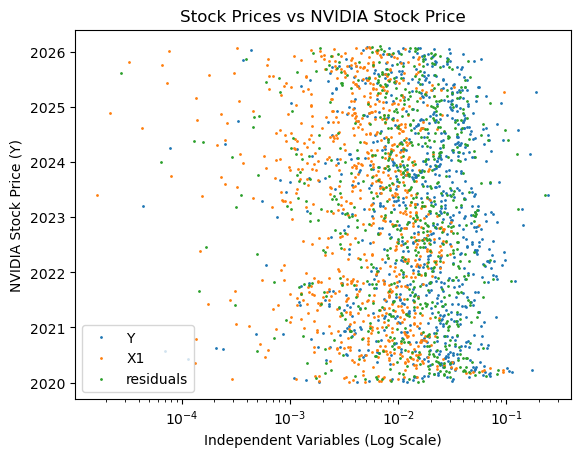

In [182]:
plot_data_log(data5)

## MODEL 6: Nasdaq

In [183]:
data6 = { 
    "Y": nvda.history(start="2020-01-01")['Close'].pct_change(),
    "X1": ndx.history(start="2020-01-01")['Close'].pct_change(),
}

In [184]:
LRM(data6)

[['X1', 1.2425775048875574]]

In [185]:
p_valueTest(data6)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     2830.
Date:                Fri, 06 Feb 2026   Prob (F-statistic):               0.00
Time:                        09:51:32   Log-Likelihood:                 3839.0
No. Observations:                1532   AIC:                            -7674.
Df Residuals:                    1530   BIC:                            -7663.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0014      0.001      2.866      0.0

In [186]:
Pagan_test(data6)

Lagrange multiplier statistic: 5.131506432954435
p-value: 0.02349532720532445
f-value: 5.142030813720132
f p-value: 0.02349226593710841


In [187]:
Whites_test(data6)

Test Statistic: 9.872967378377574
Test Statistic p-value: 0.007179800447117629
F-Statistic: 4.958773741617089
F-Test p-value: 0.007134872425046964


In [188]:
VIF_test(data6) # probably not needed

  Variable       VIF
0    const  1.002477
1       X1  1.000000


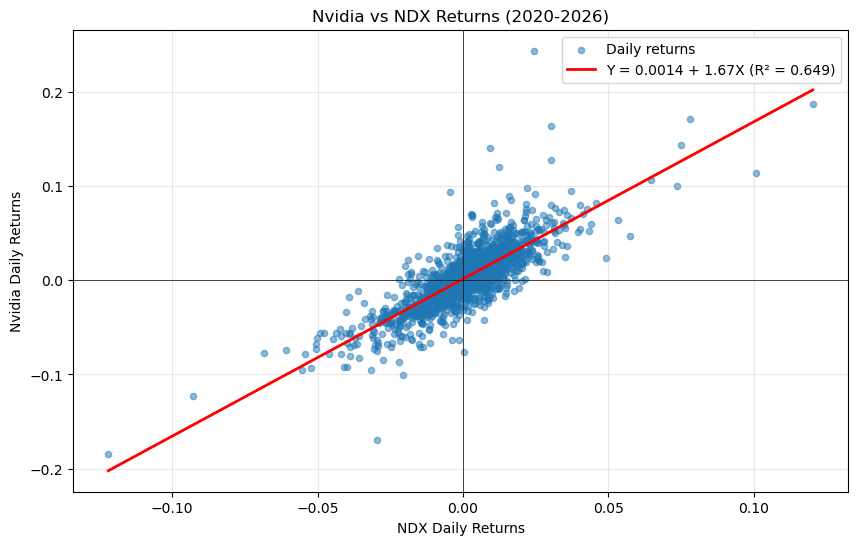

In [189]:
# Prepare data
df = pd.DataFrame(data6).dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['X1'], df['Y'], alpha=0.5, s=20, label='Daily returns')

# Add regression line
x_line = np.linspace(df['X1'].min(), df['X1'].max(), 100)
y_line = 0.0014 + 1.6695 * x_line  # Using your coefficients
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'Y = 0.0014 + 1.67X (R² = 0.649)')

plt.xlabel('NDX Daily Returns')
plt.ylabel('Nvidia Daily Returns')
plt.title('Nvidia vs NDX Returns (2020-2026)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.show()

## MODEL 7: US Congress Stock Trades

In [190]:
from congress_trades_parse import congress_trades

congress_trades

,representative,type_of_trade,amount
2025-11-12 00:00:00-05:00,Cleo Fields,Buy,"$15,001 - $50,000"
2025-11-12 00:00:00-05:00,Cleo Fields,Buy,"$100,001 - $250,000"
2025-11-10 00:00:00-05:00,Michael T. McCaul,Buy,"$100,001 - $250,000"
2025-11-03 00:00:00-05:00,"Whitehouse, Sheldon",Buy,"$15,001 - $50,000"
2025-11-18 00:00:00-05:00,Gilbert Cisneros,Buy,"$1,001 - $15,000"
...,...,...,...
2016-06-16 00:00:00-05:00,"Whitehouse, Sheldon",Buy,"$1,001 - $15,000"
2016-05-23 00:00:00-05:00,"Whitehouse, Sheldon",Buy,"$1,001 - $15,000"
2016-05-23 00:00:00-05:00,"Whitehouse, Sheldon",Buy,"$1,001 - $15,000"
2016-01-20 00:00:00-05:00,"Whitehouse, Sheldon",Buy,"$1,001 - $15,000"


In [191]:
congress_trades.head(520)

congress_trades[:520].head(60)

,representative,type_of_trade,amount
2025-11-12 00:00:00-05:00,Cleo Fields,Buy,"$15,001 - $50,000"
2025-11-12 00:00:00-05:00,Cleo Fields,Buy,"$100,001 - $250,000"
2025-11-10 00:00:00-05:00,Michael T. McCaul,Buy,"$100,001 - $250,000"
2025-11-03 00:00:00-05:00,"Whitehouse, Sheldon",Buy,"$15,001 - $50,000"
2025-11-18 00:00:00-05:00,Gilbert Cisneros,Buy,"$1,001 - $15,000"
2025-10-10 00:00:00-05:00,Valerie Hoyle,Buy,"$50,001 - $100,000"
2025-10-03 00:00:00-05:00,Ro Khanna,Buy,"$1,001 - $15,000"
2025-10-03 00:00:00-05:00,"Whitehouse, Sheldon",Buy,"$15,001 - $50,000"
2025-09-30 00:00:00-05:00,Cleo Fields,Buy,"$50,001 - $100,000"
2025-09-11 00:00:00-05:00,Michael T. McCaul,Buy,"$15,001 - $50,000"


In [192]:
nvda.history(start="2020-01-01", end="2025-7-1")['Close']

Date
2020-01-02 00:00:00-05:00      5.971077
2020-01-03 00:00:00-05:00      5.875505
2020-01-06 00:00:00-05:00      5.900144
2020-01-07 00:00:00-05:00      5.971575
2020-01-08 00:00:00-05:00      5.982775
                                ...    
2025-06-24 00:00:00-04:00    147.883408
2025-06-25 00:00:00-04:00    154.292709
2025-06-26 00:00:00-04:00    155.002625
2025-06-27 00:00:00-04:00    157.732315
2025-06-30 00:00:00-04:00    157.972305
Name: Close, Length: 1380, dtype: float64

In [193]:
date = str(nvda.history(start="2020-01-01", end="2025-7-1")['Close'].index[1])

date[:10]

'2020-01-03'

In [194]:
for i in congress_trades[:520]["amount"]:
    am1 = (i.replace("$","").replace(",",""))
    print(am1)

15001 - 50000
100001 - 250000
100001 - 250000
15001 - 50000
1001 - 15000
50001 - 100000
1001 - 15000
15001 - 50000
50001 - 100000
15001 - 50000
15001 - 50000
15001 - 50000
15001 - 50000
15001 - 50000
15001 - 50000
1001 - 15000
100001 - 250000
100001 - 250000
15001 - 50000
15001 - 50000
100001 - 250000
100001 - 250000
100001 - 250000
100001 - 250000
50001 - 100000
50001 - 100000
100001 - 250000
250001 - 500000
50001 - 100000
1001 - 15000
100001 - 250000
50001 - 100000
100001 - 250000
100001 - 250000
50001 - 100000
15001 - 50000
100001 - 250000
50001 - 100000
100001 - 250000
50001 - 100000
100001 - 250000
100001 - 250000
15001 - 50000
50001 - 100000
100001 - 250000
100001 - 250000
15001 - 50000
1001 - 15000
1001 - 15000
100001 - 250000
100001 - 250000
500001 - 1000000
1000001 - 5000000
50001 - 100000
50001 - 100000
1001 - 15000
1001 - 15000
1001 - 15000
100001 - 250000
1001 - 15000
1001 - 15000
1001 - 15000
15001 - 50000
100001 - 250000
1001 - 15000
1001 - 15000
1001 - 15000
250001 - 500

In [195]:
df = pd.DataFrame(congress_trades[:520]).replace('None', np.nan).dropna()

df["amount"].dropna().head(295)

2025-11-12 00:00:00-05:00      $15,001 - $50,000
2025-11-12 00:00:00-05:00    $100,001 - $250,000
2025-11-10 00:00:00-05:00    $100,001 - $250,000
2025-11-03 00:00:00-05:00      $15,001 - $50,000
2025-11-18 00:00:00-05:00       $1,001 - $15,000
                                    ...         
2022-12-06 00:00:00-05:00       $1,001 - $15,000
2022-12-06 00:00:00-05:00      $15,001 - $50,000
2022-11-10 00:00:00-05:00       $1,001 - $15,000
2022-11-10 00:00:00-05:00       $1,001 - $15,000
2022-11-10 00:00:00-05:00       $1,001 - $15,000
Name: amount, Length: 295, dtype: object

In [196]:
congress_trades = pd.DataFrame(congress_trades[:520]).replace('None', np.nan).dropna()

y=0

avg = []

for i in congress_trades['amount']:

    # print("######################################################")

    y+=1
    # print(y)

    # print(i)

    am1 = (i.replace("$","").replace(",",""))

    x=0

    for i in am1: 
        if i == " ":
            # print(x)
            break
        else:
            x+=1

    # print(f"num1 : {am1[:x]}")
    # print(f"num2 : {(am2[3:])}")

    num1 = float(am1[:x])

    # print(f"num1.2 : {num1}")

    num2 = float(am2[3:])
    # print(f"num2.2 : {(num2)}")

    avg_amount = (num1 + num2) / 2

    congress_trades['amount'][y-1] = avg_amount

    avg.append(avg_amount)

congress_trades['amount']

NameError: name 'am2' is not defined

In [ ]:
y = 0

for i in congress_trades['type_of_trade']: 
    if i == "Buy":
        congress_trades['type_of_trade'][y] = 1
    if i == "Sell":
        congress_trades['type_of_trade'][y] = 0

    y+=1

congress_trades['type_of_trade']

/var/folders/wb/pmxl4r0s6svgkb08w2drl86c0000gn/T/ipykernel_13586/3825601775.py:5: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  congress_trades['type_of_trade'][y] = 1
/var/folders/wb/pmxl4r0s6svgkb08w2drl86c0000gn/T/ipykernel_13586/3825601775.py:5: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  congress_trades['type_of_trade'][y] = 1
/var/folders/wb/pmxl4r0s6svgkb08w2drl86c0000gn/T/ipykernel_13586/3825601775.py:5: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value 

2025-11-12 00:00:00-05:00    1
2025-11-12 00:00:00-05:00    1
2025-11-10 00:00:00-05:00    1
2025-11-03 00:00:00-05:00    1
2025-11-18 00:00:00-05:00    1
                            ..
2020-02-03 00:00:00-05:00    1
2020-01-09 00:00:00-05:00    1
2020-01-09 00:00:00-05:00    1
2020-01-09 00:00:00-05:00    1
2020-01-02 00:00:00-05:00    1
Name: type_of_trade, Length: 516, dtype: object

In [ ]:
data7 = {
    "X1": congress_trades["amount"],
    "X2": congress_trades["representative"], # change to a descrete variable (like 1 for rep 1, 2 for rep 2, etc.)
    "X3": congress_trades["type_of_trade"], # change to binary variable (1 for buy, 0 for sell)
    "Y": nvda.history(start="2020-01-01", end="2025-7-1")['Close']
}

data7["Y"]

Date
2020-01-02 00:00:00-05:00      5.971409
2020-01-03 00:00:00-05:00      5.875832
2020-01-06 00:00:00-05:00      5.900473
2020-01-07 00:00:00-05:00      5.971908
2020-01-08 00:00:00-05:00      5.983109
                                ...    
2025-06-24 00:00:00-04:00    147.891647
2025-06-25 00:00:00-04:00    154.301300
2025-06-26 00:00:00-04:00    155.011261
2025-06-27 00:00:00-04:00    157.741104
2025-06-30 00:00:00-04:00    157.981094
Name: Close, Length: 1380, dtype: float64

In [ ]:
# Get NVDA prices
nvda_prices = nvda.history(start="2020-01-01", end="2025-11-19")['Close']

# Create a temporary DataFrame to process the data
temp_df = congress_trades[["amount", "type_of_trade"]].copy()

# Drop rows with None amounts
temp_df = temp_df.dropna(subset=['amount'])

# Map NVDA prices to each trade date
temp_df['nvda_close'] = temp_df.index.map(nvda_prices)

# Fill NaN values for NVDA close (weekends/holidays)
temp_df['nvda_close'] = temp_df['nvda_close'].fillna(0)

# Sort by date
temp_df = temp_df.sort_index(ascending=True)

# Create the data dictionary in your desired format
data6 = {
    "X1": temp_df["amount"].astype(float),
    "X2": temp_df["type_of_trade"].astype(float),
    "Y": temp_df["nvda_close"].astype(float)
}

# Now you can create a DataFrame if needed
data6_ = pd.DataFrame(data6)
data6_

,X1,X2,Y
2020-01-02 00:00:00-05:00,8000.5,1.0,5.971409
2020-01-09 00:00:00-05:00,8000.5,1.0,6.048820
2020-01-09 00:00:00-05:00,15000.5,1.0,6.048820
2020-01-09 00:00:00-05:00,8000.5,1.0,6.048820
2020-02-03 00:00:00-05:00,15000.5,1.0,5.981865
...,...,...,...
2025-11-03 00:00:00-05:00,15000.5,1.0,206.880005
2025-11-10 00:00:00-05:00,57500.5,1.0,199.050003
2025-11-12 00:00:00-05:00,57500.5,1.0,193.800003
2025-11-12 00:00:00-05:00,15000.5,1.0,193.800003


In [ ]:
str(type(data6_))

"<class 'pandas.core.frame.DataFrame'>"

In [ ]:
for i in LRM(data6_):
    print(i)

['X1', -3.614608516257431e-05]
['X2', 0.0]


In [ ]:
p_valueTest(data6_)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.5581
Date:                Tue, 02 Dec 2025   Prob (F-statistic):              0.455
Time:                        10:00:43   Log-Likelihood:                -2626.1
No. Observations:                 516   AIC:                             5256.
Df Residuals:                     514   BIC:                             5265.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
X1          1.845e-05   2.47e-05      0.747      0.4

In [ ]:
Whites_test(data6_)

Test Statistic: 0.6384304005673251
Test Statistic p-value: 0.7267191423119586
F-Statistic: 0.31775244295535354
F-Test p-value: 0.7279260691303232


In [ ]:
Pagan_test(data6_)

Lagrange multiplier statistic: 0.4393050503010776
p-value: 0.8027977015141688
f-value: 0.4379751949026798
f p-value: 0.50839793967045


Modify the code to make it so that even if the there is no congress trade that day, that it still shows up in the array to measure the effect of the congress trade relative to the effect of no congress trade. 

## MODEL 7: S&P North American Technology Sector Index

#### Import data from Excel

In [ ]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [ ]:
SPGSTI = pd.read_excel('./Data/SPGSTI.xls', sheet_name='Performance Graph')

SPGSTI[994:2525]

,Unnamed: 0,Unnamed: 1
994,2020-01-02 00:00:00,1008.87
995,2020-01-03 00:00:00,999.72
996,2020-01-06 00:00:00,1006.48
997,2020-01-07 00:00:00,1007.5
998,2020-01-08 00:00:00,1014.97
...,...,...
2520,2026-01-29 00:00:00,3234.71
2521,2026-01-30 00:00:00,3167.23
2522,2026-02-02 00:00:00,3195.23
2523,2026-02-03 00:00:00,3120.3


In [ ]:
df71 = pd.DataFrame(getRidOfTimeStamp(SPGSTI[994:2525])["Unnamed: 1"])

df71.index = pd.to_datetime(getRidOfTimeStamp(SPGSTI[994:2525])["Unnamed: 0"])

In [ ]:
df71

,Unnamed: 1
Unnamed: 0,
2020-01-02,1008.87
2020-01-03,999.72
2020-01-06,1006.48
2020-01-07,1007.5
2020-01-08,1014.97
...,...
2026-01-29,3234.71
2026-01-30,3167.23
2026-02-02,3195.23


In [ ]:
spgtsi.history(start="2020-01-01")['Close']

Date
2026-02-05 00:00:00-05:00    3016.530029
Name: Close, dtype: float64

In [ ]:
#SPGSTI

In [197]:
# Fix: Align date ranges using [1:] to skip first row and match indices
data7 = {
    "X1": df71[1:],
    "Y": getRidOfTimeStamp(nvda.history(start="2020-01-01")['Close'])[1:],
}

In [ ]:
getRidOfTimeStamp(nvda.history(start="2020-01-01")['Close'])

,Close
Date,
2020-01-02,5.971078
2020-01-03,5.875503
2020-01-06,5.900144
2020-01-07,5.971576
2020-01-08,5.982776
...,...
2026-01-30,191.130005
2026-02-02,185.610001
2026-02-03,180.339996


In [ ]:
data7 

{'X1':            Unnamed: 1
 Unnamed: 0           
 2020-01-03     999.72
 2020-01-06    1006.48
 2020-01-07     1007.5
 2020-01-08    1014.97
 2020-01-09    1025.02
 ...               ...
 2026-01-29    3234.71
 2026-01-30    3167.23
 2026-02-02    3195.23
 2026-02-03     3120.3
 2026-02-04    3032.86
 
 [1530 rows x 1 columns],
 'Y':                  Close
 Date                  
 2020-01-03    5.875505
 2020-01-06    5.900144
 2020-01-07    5.971576
 2020-01-08    5.982774
 2020-01-09    6.048483
 ...                ...
 2026-01-30  191.130005
 2026-02-02  185.610001
 2026-02-03  180.339996
 2026-02-04  174.190002
 2026-02-05  171.880005
 
 [1531 rows x 1 columns]}

In [200]:
p_valueTest(data7)

ValueError: If using all scalar values, you must pass an index

In [ ]:
Pagan_test(data7)

ValueError: zero-size array to reduction operation maximum which has no identity

In [202]:
current = np.array([4.0, 3.4, 2.8, 2.2, 1.6, 1.0])
force = np.array([1.67, 1.42, 1.16, 0.91, 0.66, 0.40])

data_physics = {
    "X1": current,
    "Y": force 
}

In [203]:
p_valueTest(data_physics)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.075e+05
Date:                Sat, 07 Feb 2026   Prob (F-statistic):           5.19e-10
Time:                        18:34:35   Log-Likelihood:                 27.102
No. Observations:                   6   AIC:                            -50.20
Df Residuals:                       4   BIC:                            -50.62
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0205      0.003     -5.877      0.0

/opt/homebrew/anaconda3/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [204]:
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(current, force)

print(f"Slope (m): {slope}")      # ~0.423 N/A
print(f"Intercept (c): {intercept}")  # ~-0.022 N
print(f"R²: {r_value**2}")  

Slope (m): 0.4228571428571429
Intercept (c): -0.020476190476190093
R²: 0.9999628020222175


## MODEL 8: Metal ETFs 

In [211]:
data8 = {
    "X1": gold_etf.history(start="2020-01-01")['Close'],
    "X2": silver_etf.history(start="2020-01-01")['Close'],
    "X3": copper_etf.history(start="2020-01-01")['Close'],
    "X4": platinum_etf.history(start="2020-01-01")['Close'],
    "X5": uranium_etf.history(start="2020-01-01")['Close'],

    "Y": nvda.history(start="2020-01-01")['Close'],
}

In [212]:
p_valueTest(data8)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     4030.
Date:                Mon, 09 Feb 2026   Prob (F-statistic):               0.00
Time:                        08:51:19   Log-Likelihood:                -6378.5
No. Observations:                1533   AIC:                         1.277e+04
Df Residuals:                    1527   BIC:                         1.280e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -65.4449      3.814    -17.157      0.0

In [213]:
Pagan_test(data8)

Lagrange multiplier statistic: 291.9487931423664
p-value: 5.3871481772251934e-61
f-value: 71.84325750058012
f p-value: 1.180072325684902e-67


In [214]:
Whites_test(data8)

Test Statistic: 528.8388573707794
Test Statistic p-value: 2.630016350147756e-99
F-Statistic: 39.81454362250037
F-Test p-value: 2.0706566127513435e-123


In [215]:
VIF_test(data8)

  Variable        VIF
0    const  92.294361
1       X1   9.303403
2       X2  17.051093
3       X3   3.061417
4       X4   7.710108
5       X5   6.072512


In [216]:
correlation_matrix(data8)

,X1,X2,X3,X4,X5
X1,1.000000,0.899549,0.715741,0.756732,0.873201
X2,0.899549,1.000000,0.710359,0.918001,0.807199
X3,0.715741,0.710359,1.000000,0.652737,0.811973
X4,0.756732,0.918001,0.652737,1.000000,0.710589
X5,0.873201,0.807199,0.811973,0.710589,1.000000


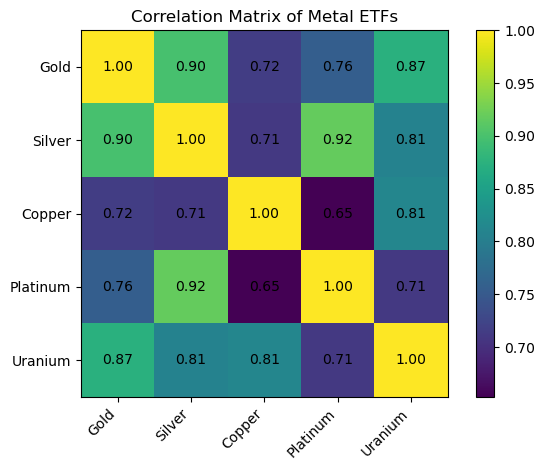

In [223]:
corr_df2 = pd.DataFrame(
    [
        [1.000000, 0.899549, 0.715741, 0.756732, 0.873201],
        [0.899549, 1.000000, 0.710359, 0.918001, 0.807199],
        [0.715741, 0.710359, 1.000000, 0.652737, 0.811973],
        [0.756732, 0.918001, 0.652737, 1.000000, 0.710589],
        [0.873201, 0.807199, 0.811973, 0.710589, 1.000000]
    ],
    columns=["Gold", "Silver", "Copper", "Platinum", "Uranium"],
    index=["Gold", "Silver", "Copper", "Platinum", "Uranium"]
)

plot_correlation_matrix_rotate(corr_df2, "Correlation Matrix of Metal ETFs")

## MODEL 9: MUDULAR NUCLEAR REACTORS.

In [230]:
data9 = {
    "X1": nuscale.history(start="2020-01-01")['Close'],
    "X2": oklo.history(start="2020-01-01")['Close'],
    "X3": ge_vernova.history(start="2020-01-01")['Close'],
    "X4": bwx.history(start="2020-01-01")['Close'],
    "X5": nano_nuclear.history(start="2020-01-01")['Close'],

    "Y": nvda.history(start="2020-01-01")['Close'],
}

In [231]:
p_valueTest(data9)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                     840.9
Date:                Mon, 09 Feb 2026   Prob (F-statistic):          1.13e-220
Time:                        12:01:18   Log-Likelihood:                -1594.9
No. Observations:                 440   AIC:                             3202.
Df Residuals:                     434   BIC:                             3226.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.3776      3.286     13.203      0.0

In [232]:
Pagan_test(data9)

Lagrange multiplier statistic: 49.072985500200424
p-value: 2.144316456269494e-09
f-value: 10.895985653146983
f p-value: 6.838966313588202e-10


In [233]:
Whites_test(data9)

Test Statistic: 138.5847361617747
Test Statistic p-value: 9.38642497145045e-20
F-Statistic: 9.6323928178616
F-Test p-value: 3.394861864439578e-24


In [234]:
VIF_test(data9)

  Variable        VIF
0    const  56.847281
1       X1   3.252240
2       X2   9.275726
3       X3   7.662576
4       X4  10.590868
5       X5   5.090562


In [249]:
correlation_matrix(data9)

,X1,X2,X3,X4,X5
X1,1.000000,0.708873,0.701035,0.606506,0.817787
X2,0.708873,1.000000,0.869783,0.913237,0.829280
X3,0.701035,0.869783,1.000000,0.909992,0.791180
X4,0.606506,0.913237,0.909992,1.000000,0.731993
X5,0.817787,0.829280,0.791180,0.731993,1.000000


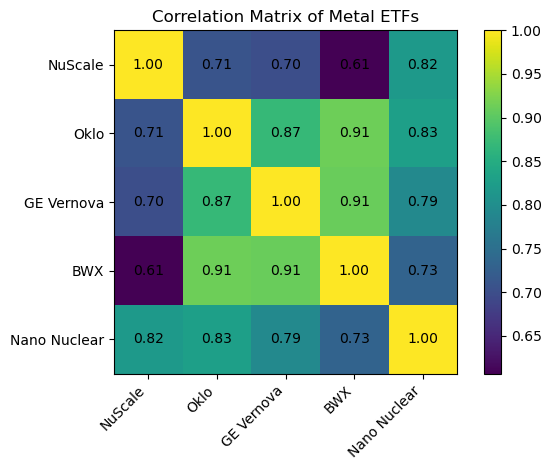

In [250]:
corr_df9 = pd.DataFrame(
    [
        [1.000000, 0.708873, 0.701035, 0.606506, 0.817787],
        [0.708873, 1.000000, 0.869783, 0.913237, 0.829280],
        [0.701035, 0.869783, 1.000000, 0.909992, 0.791180],
        [0.606506, 0.913237, 0.909992, 1.000000, 0.731993],
        [0.817787, 0.829280, 0.791180, 0.731993, 1.000000]
    ],
    columns=["NuScale", "Oklo", "GE Vernova", "BWX", "Nano Nuclear"],
    index=["NuScale", "Oklo", "GE Vernova", "BWX", "Nano Nuclear"]
)

plot_correlation_matrix_rotate(corr_df9, "Correlation Matrix of Metal ETFs")

## MODEL ULTIMATE

In [265]:
dataU = {
    "Y": nvda.history(start="2020-01-01")['Close'],
    "X1": asml.history(start="2020-01-01")['Close'],
    "X2": uranium_etf.history(start="2020-01-01")['Close'],
    "X3": ndx.history(start="2020-01-01")['Close']
}

In [266]:
p_valueTest(dataU)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     7003.
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:51:39   Log-Likelihood:                -6369.3
No. Observations:                1536   AIC:                         1.275e+04
Df Residuals:                    1532   BIC:                         1.277e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -121.1534      1.796    -67.475      0.0

In [267]:
VIF_test(dataU)

  Variable        VIF
0    const  21.102997
1       X1   4.179405
2       X2   7.562880
3       X3   7.107493


In [268]:
Pagan_test(dataU)

Lagrange multiplier statistic: 187.44540779929872
p-value: 2.1748183142433466e-40
f-value: 70.9812729395206
f p-value: 5.542056364127074e-43


In [269]:
Whites_test(dataU)

Test Statistic: 609.77115946537
Test Statistic p-value: 1.6738161089656155e-125
F-Statistic: 111.62477692362518
F-Test p-value: 1.037463341732551e-160


In [ ]:
correlation_matrix(dataU)

,X1,X2,X3
X1,1.000000,0.859099,0.849275
X2,0.859099,1.000000,0.919765
X3,0.849275,0.919765,1.000000


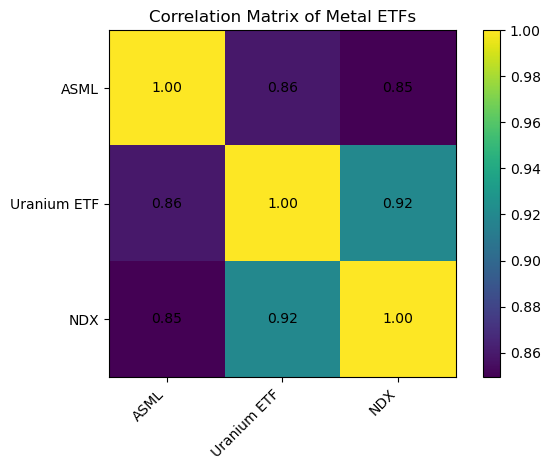

In [271]:
corr_dfU = pd.DataFrame(
    [
        [1.000000, 0.859099, 0.849275],
        [0.859099, 1.000000, 0.919765],
        [0.849275, 0.919765, 1.000000]
    ],
    columns=["ASML", "Uranium ETF", "NDX"],
    index=["ASML", "Uranium ETF", "NDX"]
)

plot_correlation_matrix_rotate(corr_dfU, "Correlation Matrix of Metal ETFs")

In [262]:
# Your data dictionary (based on your screenshot)
data = {
    'Y': nvda.history(start='2020-01-01')['Close'],
    'X1': asml.history(start='2020-01-01')['Close'],
    'X2': qcom.history(start='2020-01-01')['Close'],
    'X3': uranium_etf.history(start='2020-01-01')['Close'],
    'X4': ndx.history(start='2020-01-01')['Close']
}

df = pd.DataFrame(data)

# Prepare X and Y
Y = df['Y']
X = df[['X1', 'X2', 'X3', 'X4']]

# Add constant
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(Y, X)
results = model.fit()

# Get Newey-West HAC standard errors
# maxlags=5 is a good starting point for daily data
nw_results = results.get_robustcov_results(cov_type='HAC', maxlags=5)

print("=" * 80)
print("NEWEY-WEST (HAC) STANDARD ERRORS")
print("=" * 80)
print(nw_results.summary())

# You can also access individual values:
print("\nCoefficients with Newey-West Standard Errors:")
print(nw_results.params)
print("\nNewey-West P-values:")
print(nw_results.pvalues)
print("\nNewey-West Confidence Intervals:")
print(nw_results.conf_int())

NEWEY-WEST (HAC) STANDARD ERRORS
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     2041.
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:34:03   Log-Likelihood:                -6347.8
No. Observations:                1536   AIC:                         1.271e+04
Df Residuals:                    1531   BIC:                         1.273e+04
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -116.49

In [264]:
# Replace QCOM with TSMC
data_tsmc = {
    'Y': nvda.history(start='2020-01-01')['Close'],
    'X1': asml.history(start='2020-01-01')['Close'],
    'X2': tsmc.history(start='2020-01-01')['Close'],  # Replace QCOM with TSMC
    'X3': uranium_etf.history(start='2020-01-01')['Close'],
    'X4': ndx.history(start='2020-01-01')['Close']
}

df_tsmc = pd.DataFrame(data_tsmc)

Y = df_tsmc['Y']
X = df_tsmc[['X1', 'X2', 'X3', 'X4']]
X = sm.add_constant(X)

# Fit with Newey-West
model = sm.OLS(Y, X)
results = model.fit()
nw_results = results.get_robustcov_results(cov_type='HAC', maxlags=8)

print(nw_results.summary())

# Check VIFs
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     1928.
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:50:47   Log-Likelihood:                -6287.2
No. Observations:                1536   AIC:                         1.258e+04
Df Residuals:                    1531   BIC:                         1.261e+04
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -102.2260      7.385    -13.843      0.0